<div align="center">

# MOVIE RECOMMENDATION SYSTEM
</div>

## 🎬 Introduction

A Movie Recommendation System is a machine learning application designed to suggest movies to users based on their interests, preferences, and past interactions. With the rapid growth of online streaming platforms and digital entertainment services, recommendation systems have become an essential tool for improving user experience and helping users discover relevant content efficiently.

In this project, a movie recommendation system is developed using the MovieLens dataset containing information about movies, genres, user ratings, and timestamps. The system analyzes movie features and user behavior to generate personalized movie recommendations.

The project mainly focuses on Content-Based Filtering, where movies are recommended based on similarities in genres and movie attributes. Cosine Similarity and Count Vectorization techniques are used to measure the similarity between movies. Additionally, exploratory data analysis (EDA) and visualizations are performed to better understand rating patterns, popular genres, and user activity.

The main objectives of this project are:

* To analyze movie and rating datasets
* To perform data preprocessing and visualization
* To build a movie recommendation model
* To recommend similar movies based on user input
* To understand recommendation system techniques used in real-world applications

This project demonstrates how machine learning and data analysis techniques can be applied to create intelligent recommendation systems similar to those used by platforms like Netflix, Amazon Prime Video, and Disney+.


## 📚 Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import CountVectorizer

# Similarity Calculation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

| Library           | Purpose                           |
| ----------------- | --------------------------------- |
| pandas            | Data loading and manipulation     |
| numpy             | Numerical calculations            |
| matplotlib        | Basic plotting and charts         |
| seaborn           | Advanced data visualization       |
| CountVectorizer   | Convert text data into vectors    |
| cosine_similarity | Measure similarity between movies |
| train_test_split  | Split data for training/testing   |
| WordCloud         | Generate movie title word clouds  |
| warnings          | Hide unnecessary warnings         |


## 📂 Load Dataset

In [2]:
import shutil

shutil.copy("/kaggle/input/datasets/parasharmanas/movie-recommendation-system/movies.csv", "movies.csv")
shutil.copy("/kaggle/input/datasets/parasharmanas/movie-recommendation-system/ratings.csv", "ratings.csv")

'ratings.csv'

In [3]:
df_movies = pd.read_csv("movies.csv")
df_rating = pd.read_csv("ratings.csv")

In [4]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
df_rating.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [6]:
print("Movies Dataset Shape :", df_movies.shape)

Movies Dataset Shape : (62423, 3)


In [7]:
print("Ratings Dataset Shape :", df_rating.shape)

Ratings Dataset Shape : (25000095, 4)


In [8]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [9]:
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [10]:
df_movies.describe().T

,count,mean,std,min,25%,50%,75%,max
movieId,62423.0,122220.387646,63264.744844,1.0,82146.5,138022.0,173222.0,209171.0


In [11]:
df_rating.describe().T

,count,mean,std,min,25%,50%,75%,max
userId,25000095.0,8.118928e+04,4.679172e+04,1.0,4.051000e+04,8.091400e+04,1.215570e+05,1.625410e+05
movieId,25000095.0,2.138798e+04,3.919886e+04,1.0,1.196000e+03,2.947000e+03,8.623000e+03,2.091710e+05
rating,25000095.0,3.533854e+00,1.060744e+00,0.5,3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00
timestamp,25000095.0,1.215601e+09,2.268758e+08,789652009.0,1.011747e+09,1.198868e+09,1.447205e+09,1.574328e+09


## 🧹 Data Preprocessing

### 📌 Check Missing Values

In [12]:
# Missing values in Movies Dataset
df_movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [13]:
# Missing values in Ratings Dataset
df_rating.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

### 📌 Check Duplicate Values

In [14]:
# Duplicate values in Movies Dataset
df_movies.duplicated().sum()

np.int64(0)

In [15]:
# Duplicate values in Ratings Dataset
df_rating.duplicated().sum()

np.int64(0)

## 📌 Handle Missing Values

In [16]:
# Fill missing genres with empty string
df_movies['genres'] = df_movies['genres'].fillna('')

In [17]:
# Merge datasets
df = pd.merge(df_rating, df_movies, on='movieId')

# Display merged dataset
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [18]:
print("Merged Dataset Shape :", df.shape)

Merged Dataset Shape : (25000095, 6)


In [19]:
df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the dataset through statistics and visualizations. 

* Popular movies
* Rating patterns
* Genre distribution
* User activity
* Trends in the dataset

EDA is an important step before building the recommendation system

## 🎥 Top Rated Movies

In [20]:
# Average rating of each movie
top_rated = df.groupby('title')['rating'].mean().sort_values(ascending=False)

# Convert into dataframe
top_rated = pd.DataFrame(top_rated)

# Display top 10 rated movies
top_rated.head(10)

,rating
title,
Hitting the Cycle (2012),5.0
"Small, Beautifully Moving Parts (2012)",5.0
Podstrochnik (2009),5.0
Borrowed Time (2012),5.0
Terror of Frankenstein (1977),5.0
Hitler (1962),5.0
Hitlar (1980),5.0
Zombie Hamlet (2012),5.0
Meeting Spencer (2010),5.0


## ⭐ Most Popular Movies

In [21]:
# Count ratings for each movie
popular_movies = df.groupby('title')['rating'].count().sort_values(ascending=False)

# Convert into dataframe
popular_movies = pd.DataFrame(popular_movies)

# Display top 10 popular movies
popular_movies.head(10)

,rating
title,
Forrest Gump (1994),81491
"Shawshank Redemption, The (1994)",81482
Pulp Fiction (1994),79672
"Silence of the Lambs, The (1991)",74127
"Matrix, The (1999)",72674
Star Wars: Episode IV - A New Hope (1977),68717
Jurassic Park (1993),64144
Schindler's List (1993),60411
Braveheart (1995),59184


## 📈 Rating Distribution

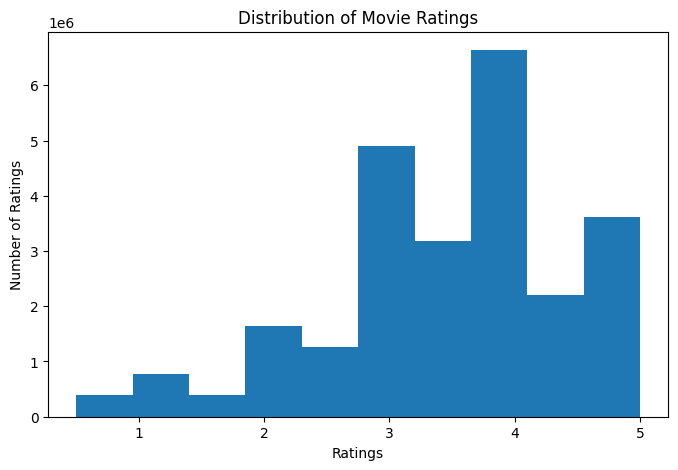

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df['rating'])

plt.xlabel("Ratings")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")

plt.show()

## 🎭 Genre Analysis

In [23]:
# Split genres
genres = df_movies['genres'].str.split('|').explode()

# Count genres
genre_count = genres.value_counts()

# Display genre counts
genre_count

genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

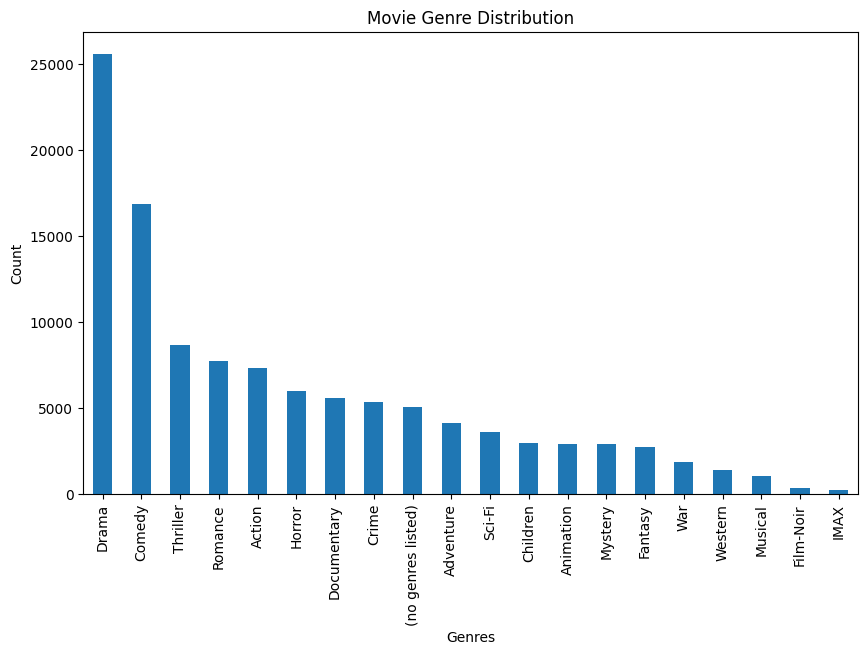

In [24]:
plt.figure(figsize=(10,6))

genre_count.plot(kind='bar')

plt.xlabel("Genres")
plt.ylabel("Count")
plt.title("Movie Genre Distribution")

plt.show()

👤 Most Active Users

In [25]:
# Extract year
df_movies['year'] = df_movies['title'].str.extract(r'\((\d{4})\)')

# Display first rows
df_movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


🎬 Movies Released Per Year

In [26]:
# Extract year
df_movies['year'] = df_movies['title'].str.extract(r'\((\d{4})\)')

# Display first rows
df_movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


📉 Movies Released Trend

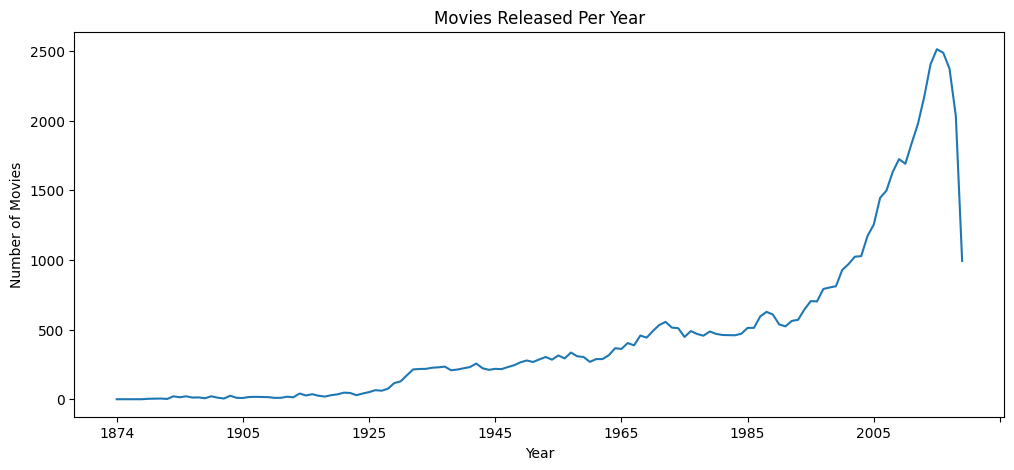

In [27]:

movies_per_year = df_movies['year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

movies_per_year.plot()

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.show()


## 🤖 Building the Movie Recommendation System

In [28]:
movies_data = df_movies[['movieId', 'title', 'genres']]

movies_data.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [29]:
movies_data['genres'] = movies_data['genres'].fillna('')

In [30]:
# Initialize CountVectorizer
cv = CountVectorizer(tokenizer=lambda x: x.split('|'))

# Convert genres into matrix
count_matrix = cv.fit_transform(movies_data['genres'])

print(count_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 112307 stored elements and shape (62423, 20)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 9)	1
  (1, 2)	1
  (1, 4)	1
  (1, 9)	1
  (2, 5)	1
  (2, 15)	1
  (3, 5)	1
  (3, 15)	1
  (3, 8)	1
  (4, 5)	1
  (5, 1)	1
  (5, 6)	1
  (5, 17)	1
  (6, 5)	1
  (6, 15)	1
  (7, 2)	1
  (7, 4)	1
  (8, 1)	1
  (9, 2)	1
  (9, 1)	1
  (9, 17)	1
  :	:
  (62407, 0)	1
  (62408, 9)	1
  (62408, 7)	1
  (62409, 19)	1
  (62410, 8)	1
  (62411, 5)	1
  (62412, 3)	1
  (62412, 7)	1
  (62413, 8)	1
  (62414, 6)	1
  (62414, 11)	1
  (62415, 0)	1
  (62416, 5)	1
  (62416, 8)	1
  (62417, 5)	1
  (62417, 15)	1
  (62417, 1)	1
  (62418, 8)	1
  (62419, 7)	1
  (62420, 5)	1
  (62420, 8)	1
  (62421, 0)	1
  (62422, 2)	1
  (62422, 8)	1
  (62422, 1)	1


In [31]:
print(count_matrix.shape)

(62423, 20)


In [32]:
tfidf = TfidfVectorizer(token_pattern=r'[^|]+')

tfidf_matrix = tfidf.fit_transform(df_movies['genres'])


In [33]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(tfidf_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [34]:
def recommend(movie_name):

    movie_name = movie_name.lower()

    # Find movie index
    idx = df_movies[
        df_movies['title'].str.lower() == movie_name
    ].index

    if len(idx) == 0:
        print("Movie not found!")
        return

    idx = idx[0]

    # Find nearest neighbors
    distances, indices = model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=11
    )

    print(f"\n🎬 Recommended Movies for '{df_movies.iloc[idx]['title']}'\n")

    for i in range(1, len(indices[0])):

        movie_idx = indices[0][i]

        print(df_movies.iloc[movie_idx]['title'])

In [35]:
recommend("Toy Story (1995)")


🎬 Recommended Movies for 'Toy Story (1995)'

UglyDolls (2019)
Brother Bear 2 (2006)
Antz (1998)
Olaf's Frozen Adventure (2017)
Wonder Park (2019)
Missing Link (2019)
Moana (2016)
The Magic Crystal (2011)
Scooby-Doo! Mask of the Blue Falcon (2012)
Wild, The (2006)


In [36]:
recommend("Jumanji (1995)")


🎬 Recommended Movies for 'Jumanji (1995)'

Jumanji (1995)
NeverEnding Story III, The (1994)
Alice Through the Looking Glass (2016)
Polar Bear King, The (Kvitebjørn Kong Valemon) (1991)
Red Riding Hood (1989)
Three Fat Men (1966)
Little Ghost (1997)
Red, Honest, in Love (1984)
Alice in Wonderland (1933)
Chronicles of Narnia: The Voyage of the Dawn Treader, The (2010)


In [37]:
recommend("Heat (1995)")


🎬 Recommended Movies for 'Heat (1995)'

Time and Tide (Seunlau Ngaklau) (2000)
Stone (1974)
Rånarna (2003)
Revolver (1973)
Hitman (2007)
Johan Falk: Kodnamn Lisa (2013)
Kill! (1971)
Johan Falk: De 107 patrioterna (2012)
Prey, The (La proie) (2011)
Angel of Death (2009)


In [38]:
recommend("ABC Movie")

Movie not found!


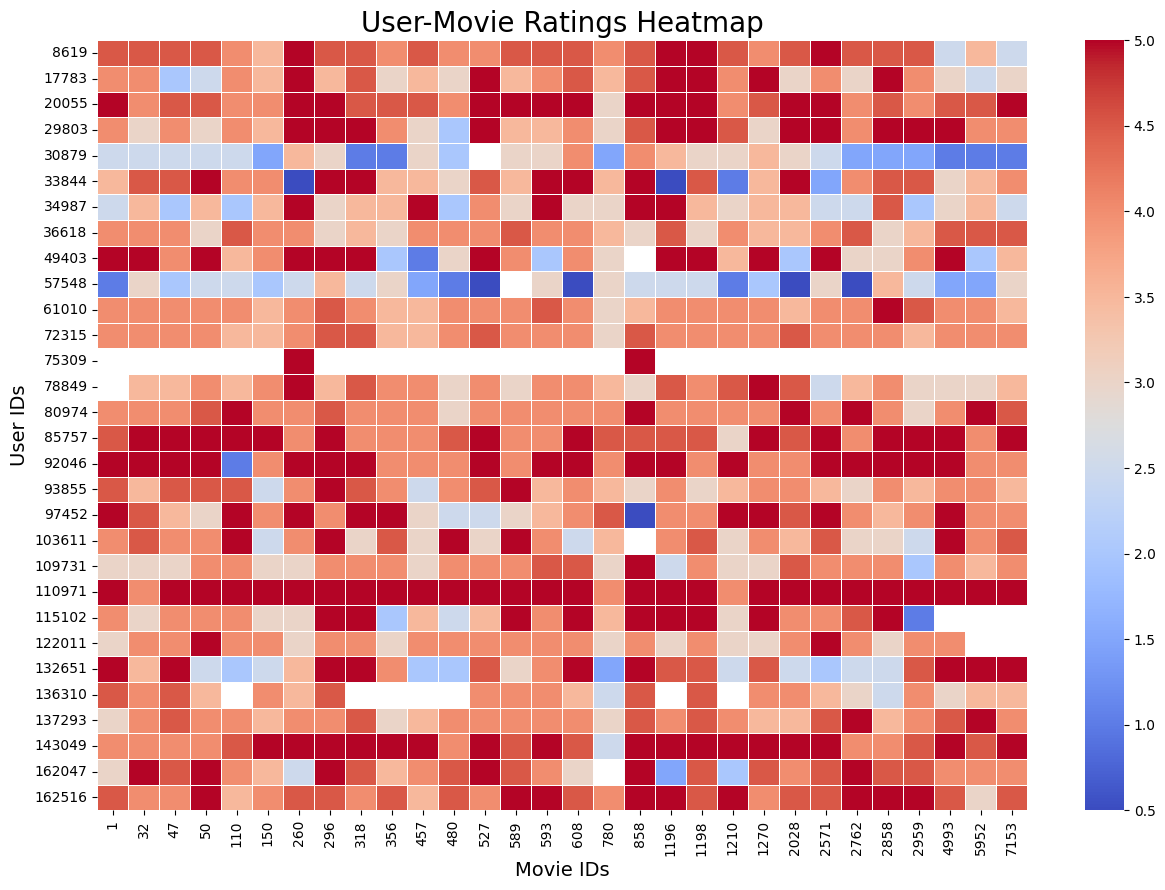

In [39]:
# ==========================================
# USER-MOVIE RATINGS HEATMAP
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload data after kernel restart
df_rating = pd.read_csv("ratings.csv", dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Filter to top 30 users and top 30 movies BEFORE pivot
top_movies = df_rating['movieId'].value_counts().head(30).index
top_users  = df_rating['userId'].value_counts().head(30).index

filtered = df_rating[
    df_rating['movieId'].isin(top_movies) &
    df_rating['userId'].isin(top_users)
]

# Create User-Movie Matrix
movie_matrix = filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Select smaller portion for visualization
heatmap_data = movie_matrix.iloc[:30, :30]

# Create Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

# Titles and Labels
plt.title("User-Movie Ratings Heatmap", fontsize=20)
plt.xlabel("Movie IDs", fontsize=14)
plt.ylabel("User IDs", fontsize=14)

plt.show()